# K-SVD Analysis
Notebook for quick k-SVD experiments, visualization, and hyperparameter exploration.

## Image Experiments

1. Classical k-SVD (for fully observed data)

- for denoising of images:

    1. extract patches from the noisy image
    2. train dictionary
    3. sparse reconstruct patches
    4. aggregate reconstructed patches


In [4]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import seaborn as sns
import numpy as np

PROJECT_ROOT = Path.cwd().parent
IMAGE_PATH = Path(PROJECT_ROOT) / "data" / "CBSD68"
NETFLIX_PATH = Path(PROJECT_ROOT) / "data" / "netflix"
RESULTS_PATH = Path(PROJECT_ROOT) / "results" / "ksvd"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.ksvd.ksvd import ksvd, initialize_dictionary
from src.ksvd.patches import extract_patches, reconstruct_from_patches
from src.ksvd.omp import *
from src.utils.masking import create_mask, apply_mask, create_netflix_mask
from src.utils.noise import add_gaussian_noise, add_pairflip_noise, add_symmetric_noise
from src.utils.io import load_image, load_netflix_matrix
from src.utils.metrics import mse, nmse, psnr, rmse, nrmse

from experiments.config import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def show_results(X, X_rec, X_noisy=None, X_masked=None, title=""):
    plt.figure(figsize=(12, 4))

    if X_noisy is not None:
        plt.subplot(1, 3, 1)
        plt.imshow(X, cmap="gray", vmin=0, vmax=255)
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(X_noisy, cmap='gray', vmin=0, vmax=255)
        plt.title("Noisy")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(X_rec, cmap="gray", vmin=0, vmax=255)
        plt.title("Denoised")
        plt.axis("off")

    else:
        plt.subplot(1, 3, 1)
        plt.imshow(X, cmap='gray', vmin=0, vmax=255)
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(X_masked, cmap='gray', vmin=0, vmax=255)
        plt.title("Observed pixels")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(X_rec, cmap='gray', vmin=0, vmax=255)
        plt.title("Reconstructed")
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

In [9]:
REC_PATH = RESULTS_PATH / "images" / "reconstruction"
DEN_PATH = RESULTS_PATH / "images" / "denoising"

rec = pd.read_csv(REC_PATH / "results.csv")
den = pd.read_csv(DEN_PATH / "results.csv")

rec_avg = rec.groupby("missing_fraction")["PSNR"].mean()
den_avg = den.groupby("sigma")["PSNR"].mean()
rec_std = rec.groupby("missing_fraction")["PSNR"].std()
den_std = den.groupby("sigma")["PSNR"].std()

print(f"Reconstruction Observed Fraction vs. PSNR: {rec_avg}")
print(f"Denoising Noise Level vs. PSNR: {den_avg}")
print(f"Reconstruction PSNR Std Dev: {rec_std}")
print(f"Denoising PSNR Std Dev: {den_std}")

Reconstruction Observed Fraction vs. PSNR: missing_fraction
0.2    33.835593
0.4    29.519477
0.6    25.913858
Name: PSNR, dtype: float64
Denoising Noise Level vs. PSNR: sigma
12.75    29.427071
25.50    26.634249
51.00    23.235785
Name: PSNR, dtype: float64
Reconstruction PSNR Std Dev: missing_fraction
0.2    4.232364
0.4    4.162102
0.6    4.012476
Name: PSNR, dtype: float64
Denoising PSNR Std Dev: sigma
12.75    2.905446
25.50    2.000893
51.00    1.553211
Name: PSNR, dtype: float64


### **Image Denoising** (adaptive dictionary) 

= removes noise by learning specialized, "adapted" dictionary atoms directly from the noisy image itself, rather than using a fixed, predefined basis (like DCT or Wavelets)

- sigma = 25.5, sparsity = 4

In [ ]:
# Denoising
X = load_image(IMAGE_PATH / "0047.png")
X = X[:256, :256]

# 1: Add Gaussian noise to the image
sigma = 0.1 * 255  # sigma = 0.1 * 255 = 25.5
# sigma = 0.1  # sigma = 0.1 in [0,1] range
X_noisy = add_gaussian_noise(X, sigma=sigma)

# 2: Extract overlapping patches from the noisy image
patches = extract_patches(X_noisy, patch_size=8, stride=1)

# 3: Learn a dictionary and sparse codes using K-SVD from the noisy patches
D, X, history = ksvd(
    patches,
    n_atoms=256,
    sparsity=4,
    n_iter=10,
    random_state=42,
    verbose=True
)

# 4: Reconstruct patches from the learned dictionary and sparse codes
reconstructed_patches = D @ X

iter 01: objective = 1.967100e+09
iter 02: objective = 1.949259e+09, rel_change = 9.070e-03
iter 03: objective = 1.934973e+09, rel_change = 7.329e-03
iter 04: objective = 1.919282e+09, rel_change = 8.109e-03
iter 05: objective = 1.902090e+09, rel_change = 8.957e-03
iter 06: objective = 1.884137e+09, rel_change = 9.439e-03
iter 07: objective = 1.865519e+09, rel_change = 9.881e-03
iter 08: objective = 1.848629e+09, rel_change = 9.054e-03
iter 09: objective = 1.833715e+09, rel_change = 8.067e-03
iter 10: objective = 1.819931e+09, rel_change = 7.517e-03


ValueError: positions and patches disagree on number of patches.

PSNR: 27.66320673362587 dB


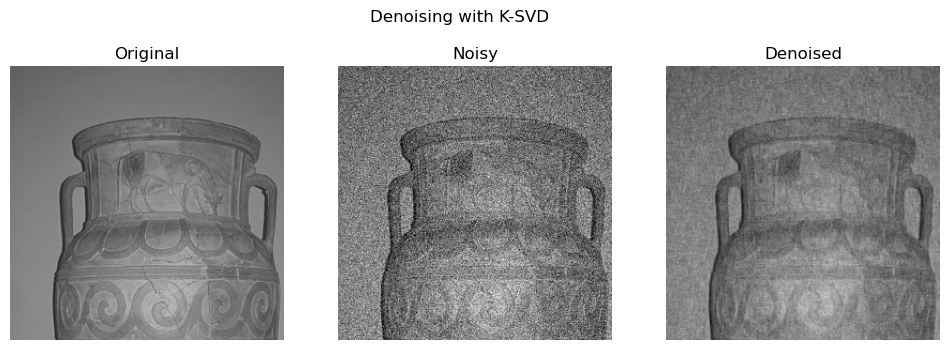

In [ ]:
img = load_image(IMAGE_PATH / "0047.png")
img = img[:256, :256]

# 5: Aggregate overlapping reconstructed patches back into the full image by averaging
X_rec = reconstruct_from_patches(reconstructed_patches, image_shape=img.shape, patch_size=8, stride=1)

print(f"PSNR: {psnr(img, X_rec, data_range=255)} dB")

show_results(img, X_rec, X_noisy=X_noisy, title="Denoising with K-SVD")

Text(0, 0.5, 'Objective')

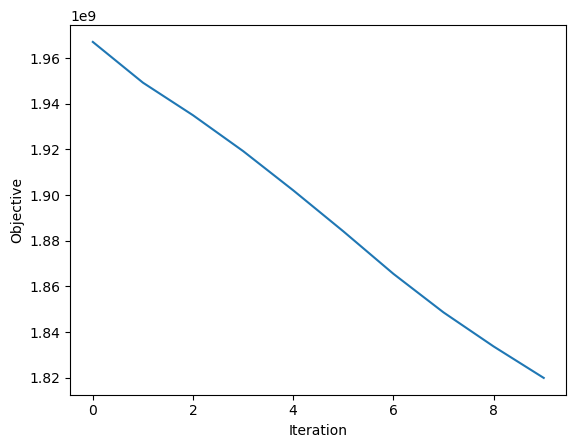

In [ ]:
# atoms = D[:, i].reshape(8, 8)
# Show the objective loss history over iterations
plt.figure(figsize=(8, 5))
plt.plot(history["objective"], marker="o")
plt.title("K-SVD Objective Loss History")
plt.xlabel("Iteration")
plt.ylabel("Objective Loss")
plt.show()

If we normalize the image to range [0, 1], there is no change in the results:

In [3]:
# Denoising
X = load_image(IMAGE_PATH / "0047.png", normalize=True)
X = X[:256, :256]

# 1: Add Gaussian noise to the image
# sigma = 0.1 * 255  # sigma = 0.1 * 255 = 25.5
sigma = 0.1  # sigma = 0.1 in [0,1] range
X_noisy = add_gaussian_noise(X, sigma=sigma, normalize=True)

# 2: Extract overlapping patches from the noisy image
patches = extract_patches(X_noisy, patch_size=8, stride=1)

# 3: Learn a dictionary and sparse codes using K-SVD from the noisy patches
D, X, history = ksvd(
    patches,
    n_atoms=256,
    sparsity=4,
    n_iter=10,
    random_state=42,
    verbose=True
)

# 4: Reconstruct patches from the learned dictionary and sparse codes
reconstructed_patches = D @ X

iter 01: objective = 3.069957e+04
iter 02: objective = 3.041063e+04, rel_change = 9.412e-03
iter 03: objective = 3.022476e+04, rel_change = 6.112e-03
iter 04: objective = 3.002178e+04, rel_change = 6.716e-03
iter 05: objective = 2.978336e+04, rel_change = 7.941e-03
iter 06: objective = 2.952612e+04, rel_change = 8.637e-03
iter 07: objective = 2.925398e+04, rel_change = 9.217e-03
iter 08: objective = 2.899133e+04, rel_change = 8.978e-03
iter 09: objective = 2.874996e+04, rel_change = 8.326e-03
iter 10: objective = 2.853273e+04, rel_change = 7.556e-03


PSNR: 27.667232644683093 dB


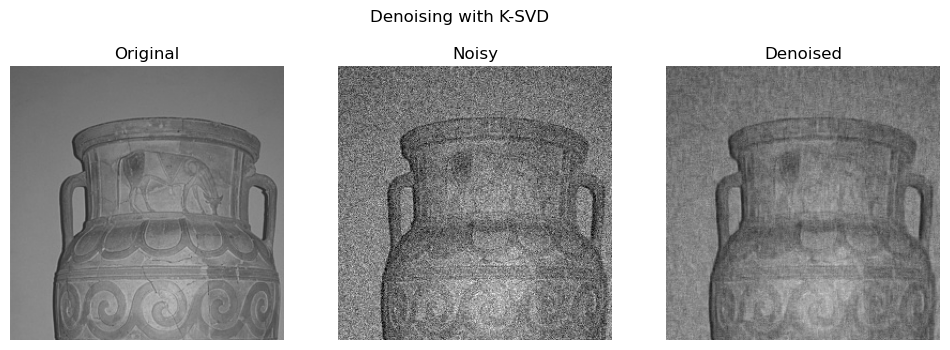

In [4]:
img = load_image(IMAGE_PATH / "0047.png", normalize=True)
img = img[:256, :256]

# 5: Aggregate overlapping reconstructed patches back into the full image by averaging
X_rec = reconstruct_from_patches(reconstructed_patches, image_shape=img.shape, patch_size=8, stride=1)
X_rec = np.clip(X_rec, 0, 1)

print(f"PSNR: {psnr(img, X_rec, data_range=1.0)} dB")

show_results(img, X_rec, X_noisy=X_noisy, title="Denoising with K-SVD")

Image Denoising with sigma=25.5, sparsity=6

In [ ]:
# Denoising
X = load_image(IMAGE_PATH / "0047.png")
X = X[:256, :256]

sigma = 0.1 * 255  # sigma = 0.1 * 255 = 25.5
# sigma = 0.1  # sigma = 0.1 in [0,1] range
X_noisy = add_gaussian_noise(X, sigma=sigma)

patches = extract_patches(X_noisy, patch_size=8, stride=1)

# Sparsity = 6 gives lower PSNR than sparsity = 4, and atoms are less interpretable
D, codes, history = ksvd(
    patches,
    n_atoms=256,
    sparsity=6,
    n_iter=10,
    random_state=42,
    verbose=True
)

reconstructed_patches = D @ codes

iter 01: objective = 1.626112e+09
iter 02: objective = 1.603247e+09, rel_change = 1.406e-02
iter 03: objective = 1.588770e+09, rel_change = 9.030e-03
iter 04: objective = 1.576607e+09, rel_change = 7.656e-03
iter 05: objective = 1.565547e+09, rel_change = 7.015e-03
iter 06: objective = 1.554801e+09, rel_change = 6.865e-03
iter 07: objective = 1.544295e+09, rel_change = 6.757e-03
iter 08: objective = 1.534053e+09, rel_change = 6.632e-03
iter 09: objective = 1.523403e+09, rel_change = 6.942e-03
iter 10: objective = 1.513177e+09, rel_change = 6.713e-03


PSNR: 25.92408010216458 dB


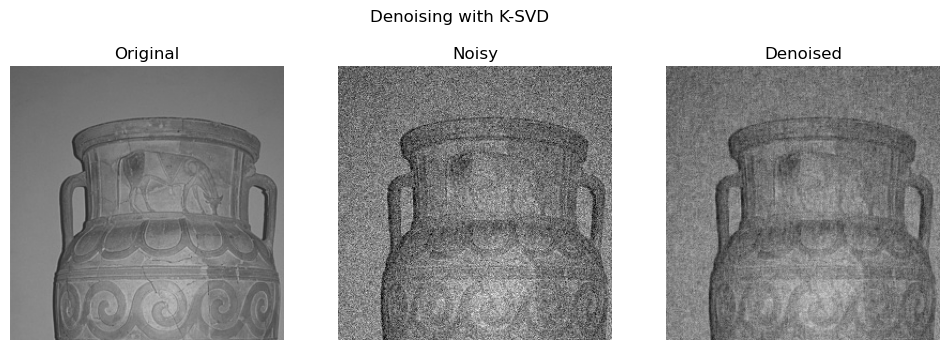

In [18]:
X_rec = reconstruct_from_patches(reconstructed_patches, image_shape=X.shape, patch_size=8, stride=1)

print(f"PSNR: {psnr(X, X_rec, data_range=255)} dB")

show_results(X, X_rec, X_noisy=X_noisy, title="Denoising with K-SVD")

Image Denoising with sigma=25.5, sparsity=4, fixed_atoms=1 -> ~26

In [5]:
# Denoising
X = load_image(IMAGE_PATH / "0047.png")
X = X[:256, :256]

sigma = 0.1 * 255  # sigma = 0.1 * 255 = 25.5
# sigma = 0.1  # sigma = 0.1 in [0,1] range
X_noisy = add_gaussian_noise(X, sigma=sigma)

patches = extract_patches(X_noisy, patch_size=8, stride=1)

In [6]:
D, codes, history = ksvd(
    patches,
    n_atoms=512,
    sparsity=4,
    n_iter=10,
    fixed_atoms=1,
    random_state=42,
    verbose=True
)

# DC atom
D[:, 0] = np.ones(D.shape[0]) / np.sqrt(D.shape[0])

reconstructed_patches = D @ codes

iter 01: objective = 1.883499e+09
iter 02: objective = 1.847858e+09, rel_change = 1.892e-02
iter 03: objective = 1.814221e+09, rel_change = 1.820e-02
iter 04: objective = 1.784227e+09, rel_change = 1.653e-02
iter 05: objective = 1.756945e+09, rel_change = 1.529e-02
iter 06: objective = 1.734070e+09, rel_change = 1.302e-02
iter 07: objective = 1.714189e+09, rel_change = 1.146e-02
iter 08: objective = 1.697269e+09, rel_change = 9.870e-03
iter 09: objective = 1.682234e+09, rel_change = 8.858e-03
iter 10: objective = 1.669182e+09, rel_change = 7.759e-03


PSNR: 26.813141447229192 dB


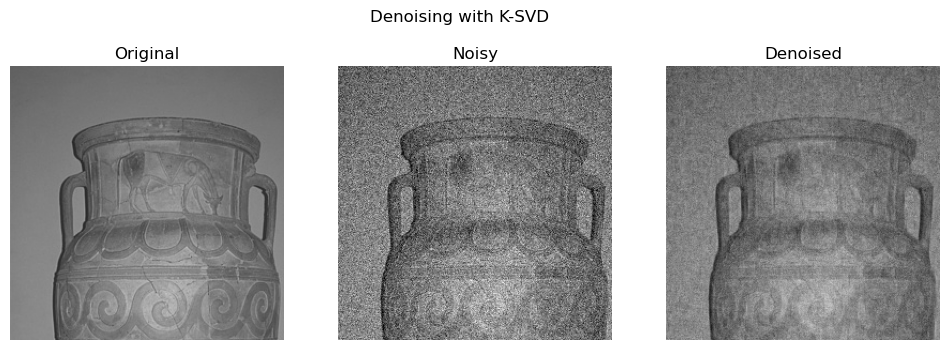

In [7]:
X_rec = reconstruct_from_patches(reconstructed_patches, image_shape=X.shape, patch_size=8, stride=1)

print(f"PSNR: {psnr(X, X_rec, data_range=255)} dB")

show_results(X, X_rec, X_noisy=X_noisy, title="Denoising with K-SVD")

In [3]:
X = load_image(IMAGE_PATH / "0065.png")
X = X[:256, :256]

# Add noise
sigma = 25.5
X_noisy = add_gaussian_noise(X, sigma=sigma)

# Extract overlapping patches
patches = extract_patches(
    X_noisy,
    patch_size=8,
    stride=1,
)

n_patches = patches.shape[1]

initial_dictionary = initialize_dictionary(
    patches,
    n_atoms=128,
    random_state=42,
    )

# Insert fixed DC atom
initial_dictionary[:, 0] = np.ones(initial_dictionary.shape[0]) / np.sqrt(
    initial_dictionary.shape[0]
)

D, codes, history = ksvd(
    patches,
    n_atoms=128,
    sparsity=2,
    n_iter=10,
    initial_dictionary=initial_dictionary,
    fixed_atoms=1,
    random_state=42,
    verbose=True,
)

reconstructed_patches = D @ codes

X_rec = reconstruct_from_patches(
            reconstructed_patches,
            image_shape=X.shape,
            patch_size=8,
            stride=1,
        )

X_rec = np.clip(X_rec, 0, 255)

iter 01: objective = 3.358752e+09
iter 02: objective = 3.198702e+09, rel_change = 4.765e-02
iter 03: objective = 3.131669e+09, rel_change = 2.096e-02
iter 04: objective = 3.089120e+09, rel_change = 1.359e-02
iter 05: objective = 3.062033e+09, rel_change = 8.769e-03
iter 06: objective = 3.045015e+09, rel_change = 5.558e-03
iter 07: objective = 3.032827e+09, rel_change = 4.002e-03
iter 08: objective = 3.024366e+09, rel_change = 2.790e-03
iter 09: objective = 3.017835e+09, rel_change = 2.159e-03
iter 10: objective = 3.012505e+09, rel_change = 1.766e-03


PSNR: 25.193642479715823 dB
NRMSE: 0.05499432501598674


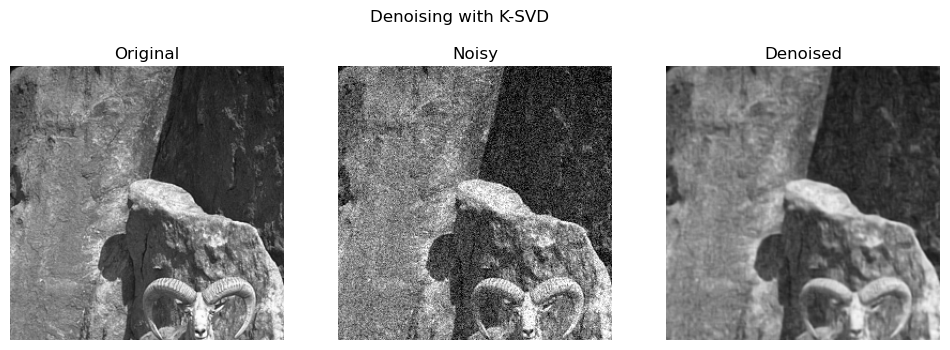

In [4]:
print(f"PSNR: {psnr(X, X_rec, data_range=255)} dB")
print(f"NRMSE: {nrmse(X, X_rec, data_range=255)}")
show_results(X, X_rec, X_noisy=X_noisy, title="Denoising with K-SVD")

In [5]:
X = load_image(IMAGE_PATH / "0065.png")
X = X[:256, :256]

# Add noise
sigma = 25.5
X_noisy = add_gaussian_noise(X, sigma=sigma)

# Extract overlapping patches
patches = extract_patches(
    X_noisy,
    patch_size=8,
    stride=1,
)

n_patches = patches.shape[1]

initial_dictionary = initialize_dictionary(
    patches,
    n_atoms=256,
    random_state=42,
    )

# Insert fixed DC atom
initial_dictionary[:, 0] = np.ones(initial_dictionary.shape[0]) / np.sqrt(
    initial_dictionary.shape[0]
)

D, codes, history = ksvd(
    patches,
    n_atoms=256,
    sparsity=4,
    n_iter=10,
    initial_dictionary=initial_dictionary,
    fixed_atoms=1,
    random_state=42,
    verbose=True,
)

reconstructed_patches = D @ codes

X_rec = reconstruct_from_patches(
            reconstructed_patches,
            image_shape=X.shape,
            patch_size=8,
            stride=1,
        )

X_rec = np.clip(X_rec, 0, 255)

iter 01: objective = 2.602263e+09
iter 02: objective = 2.498824e+09, rel_change = 3.975e-02
iter 03: objective = 2.452295e+09, rel_change = 1.862e-02
iter 04: objective = 2.423776e+09, rel_change = 1.163e-02
iter 05: objective = 2.403186e+09, rel_change = 8.495e-03
iter 06: objective = 2.386259e+09, rel_change = 7.044e-03
iter 07: objective = 2.372869e+09, rel_change = 5.611e-03
iter 08: objective = 2.360693e+09, rel_change = 5.131e-03
iter 09: objective = 2.350273e+09, rel_change = 4.414e-03
iter 10: objective = 2.340636e+09, rel_change = 4.100e-03


PSNR: 25.577972681867152 dB
NRMSE: 0.0526140055056898


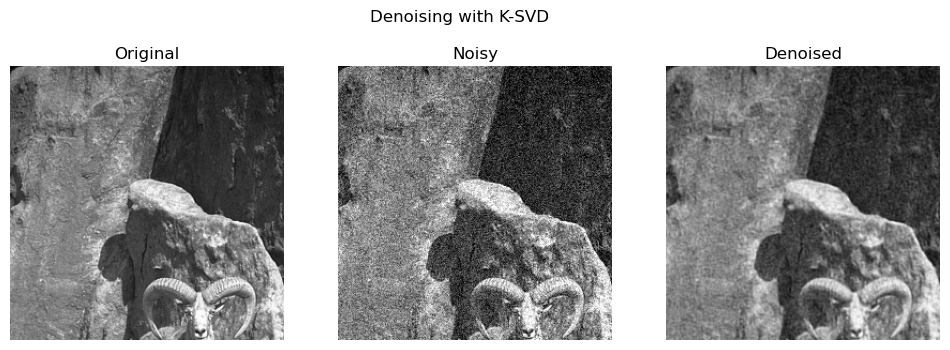

In [6]:
print(f"PSNR: {psnr(X, X_rec, data_range=255)} dB")
print(f"NRMSE: {nrmse(X, X_rec, data_range=255)}")
show_results(X, X_rec, X_noisy=X_noisy, title="Denoising with K-SVD")

2. Masked k-SVD

- keep the dictionary update and add masked sparse coding and masked reconstruction loss

### **Missing-pixel reconstruction / inpainting**

1. Transductive approach: the dictionary is pre-learned and fixed at test time
- k-SVD inpainting design = learn a dictionary from clean data, then apply masked OMP on the corrupted (**as described in the paper**)
- alternative self-supervised approach: masked K-SVD on the same image

In [5]:
def reconstruct_image_with_mask(
    image_corrupted: np.ndarray,
    mask: np.ndarray,
    D: np.ndarray,
    patch_size: int = 8,
    stride: int = 8,
    sparsity: int = 10,
):
    """
    Reconstruct an image from masked observations using a fixed learned dictionary.

    image_corrupted: image with missing pixels already set to 0
    mask: 1/True for observed pixels, 0/False for missing pixels
    """
    # 3: Extract patches and patch positions from the corrupted image
    patches, positions = extract_patches(
        image_corrupted,
        patch_size=patch_size,
        stride=stride,
        return_positions=True,
    )

    # Extract the corresponding patch masks
    patch_masks = extract_patches(
        mask.astype(float),
        patch_size=patch_size,
        stride=stride,
    ).astype(bool)

    # 4: Sparse coding with mask-aware OMP - only observed pixels
    codes = omp_batch(
        patches,
        D,
        sparsity=sparsity,
        masks=patch_masks,
        normalize_masked_dictionary=True,
    )

    # 5: Reconstruct patches and aggregate
    reconstructed_patches = D @ codes
    image_rec = reconstruct_from_patches(
        reconstructed_patches,
        image_shape=image_corrupted.shape,
        patch_size=patch_size,
        stride=stride,
        positions=positions,
    )

    # keep observed pixels exactly as they were
    image_rec = mask * image_corrupted + (1 - mask) * image_rec

    return image_rec, codes

In [6]:
clean_train_image = load_image(IMAGE_PATH / "0065.png")
clean_train_image = clean_train_image[:256, :256]

test_image = load_image(IMAGE_PATH / "0047.png")
test_image = test_image[:256, :256]

In [ ]:
# 1: Train on clean patches = Learn dictionary from clean/full patches
train_patches = extract_patches(clean_train_image, patch_size=8, stride=8)

D, X_train, history = ksvd(
    train_patches,
    n_atoms=441,      # paper used 64 x 441 dictionary
    sparsity=10,      # paper used up to 10 coefficients
    n_iter=20,
    fixed_atoms=1,    # if we include a DC atom
    random_state=42,
    verbose=True,
)

# Build a DC atom to match the paper
D[:, 0] = np.ones(D.shape[0]) / np.sqrt(D.shape[0])

iter 01: objective = 2.507432e+06
iter 02: objective = 1.826217e+06, rel_change = 2.717e-01
iter 03: objective = 1.576219e+06, rel_change = 1.369e-01
iter 04: objective = 1.464037e+06, rel_change = 7.117e-02
iter 05: objective = 1.394274e+06, rel_change = 4.765e-02
iter 06: objective = 1.327905e+06, rel_change = 4.760e-02
iter 07: objective = 1.295374e+06, rel_change = 2.450e-02
iter 08: objective = 1.270028e+06, rel_change = 1.957e-02
iter 09: objective = 1.240393e+06, rel_change = 2.333e-02
iter 10: objective = 1.231714e+06, rel_change = 6.997e-03
iter 11: objective = 1.205711e+06, rel_change = 2.111e-02
iter 12: objective = 1.197677e+06, rel_change = 6.664e-03
iter 13: objective = 1.182322e+06, rel_change = 1.282e-02
iter 14: objective = 1.159544e+06, rel_change = 1.927e-02
iter 15: objective = 1.146283e+06, rel_change = 1.144e-02
iter 16: objective = 1.139817e+06, rel_change = 5.641e-03
iter 17: objective = 1.128862e+06, rel_change = 9.611e-03
iter 18: objective = 1.115319e+06, rel

TypeError: create_mask() got an unexpected keyword argument 'missing_rate'

In [ ]:
# 2: Corrupt a test image with a random mask
mask = create_mask(test_image.shape, observed_fraction=0.6)  # or similar
X_corrupted = test_image.copy()
X_corrupted[~mask] = 0

# Reconstruct
X_rec, codes = reconstruct_image_with_mask(
    X_corrupted,
    mask,
    D,
    patch_size=8,
    stride=8,
    sparsity=10,
)

PSNR: 32.402904706205874 dB
NRMSE: 0.023980308434469057 dB


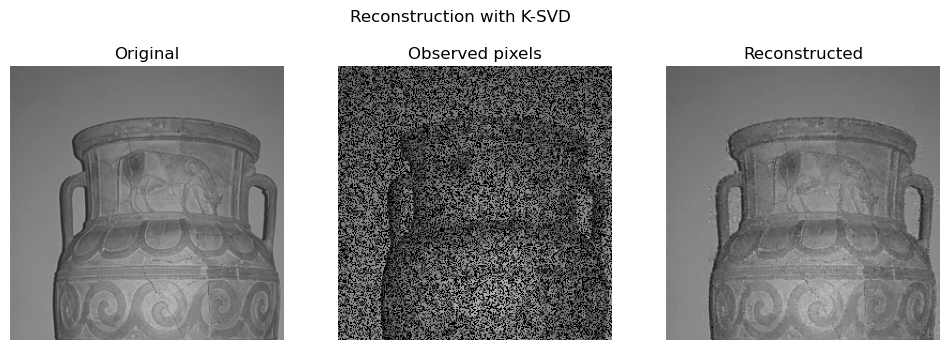

In [23]:
print(f"PSNR: {psnr(test_image, X_rec, data_range=255)} dB")
print(f"NRMSE: {nrmse(test_image, X_rec, data_range=255)} dB")

show_results(test_image, X_rec, X_masked = X_corrupted, title="Reconstruction with K-SVD")

SVT reconstruction task on image 0047 for 40% missing entries: 23.1099 PSNR, 0.0699 NRMSE

k-SVD reconstruction task on image 0047  for 40% missing entries: 32.403 PSNR, 0.02399 NRMSE

2. Self-supervised approach

In [7]:
mask = create_mask(test_image.shape, observed_fraction=0.6)

X_corrupted = test_image.copy()
X_corrupted[~mask] = 0

patches_corrupted, positions = extract_patches(
    X_corrupted,
    patch_size=8,
    stride=8,
    return_positions=True,
)

patch_masks = extract_patches(
    mask.astype(float),
    patch_size=8,
    stride=8,
).astype(bool)

In [8]:
# Initialize dictionary with patches from the corrupted image (only observed pixels contribute)
initial_dictionary = initialize_dictionary(
    patches_corrupted,
    n_atoms=441,
    random_state=42,
)

# Set the first atom to be the DC atom to match the paper's approach of using a fixed DC atom
initial_dictionary[:, 0] = (
    np.ones(initial_dictionary.shape[0]) /
    np.sqrt(initial_dictionary.shape[0])
)

D_masked, X_masked, history = ksvd(
    patches_corrupted,
    n_atoms=441,
    sparsity=10,
    n_iter=20,
    masks=patch_masks,
    fixed_atoms=1,
    initial_dictionary=initial_dictionary,
    random_state=42,
)

iter 01: objective = 9.230439e+05
iter 02: objective = 7.452987e+05, rel_change = 1.926e-01
iter 03: objective = 5.971471e+05, rel_change = 1.988e-01
iter 04: objective = 5.107756e+05, rel_change = 1.446e-01
iter 05: objective = 4.377202e+05, rel_change = 1.430e-01
iter 06: objective = 4.067015e+05, rel_change = 7.086e-02
iter 07: objective = 3.794907e+05, rel_change = 6.691e-02
iter 08: objective = 3.668907e+05, rel_change = 3.320e-02
iter 09: objective = 3.547755e+05, rel_change = 3.302e-02
iter 10: objective = 3.353227e+05, rel_change = 5.483e-02
iter 11: objective = 3.438358e+05, rel_change = 2.539e-02
iter 12: objective = 3.362331e+05, rel_change = 2.211e-02
iter 13: objective = 3.246219e+05, rel_change = 3.453e-02
iter 14: objective = 3.203008e+05, rel_change = 1.331e-02
iter 15: objective = 3.120403e+05, rel_change = 2.579e-02
iter 16: objective = 3.152659e+05, rel_change = 1.034e-02
iter 17: objective = 3.142161e+05, rel_change = 3.330e-03
iter 18: objective = 3.161836e+05, rel

In [9]:
reconstructed_patches = D_masked @ X_masked

X_rec = reconstruct_from_patches(
    reconstructed_patches,
    image_shape=X_corrupted.shape,
    patch_size=8,
    stride=8,
    positions=positions,
)

X_rec = mask * X_corrupted + (1 - mask) * X_rec

print(f"PSNR: {psnr(test_image, X_rec, data_range=255)} dB")
print(f"NRMSE: {nrmse(test_image, X_rec, data_range=255)}")

PSNR: 15.483856499411974 dB
NRMSE: 0.16819271265117197


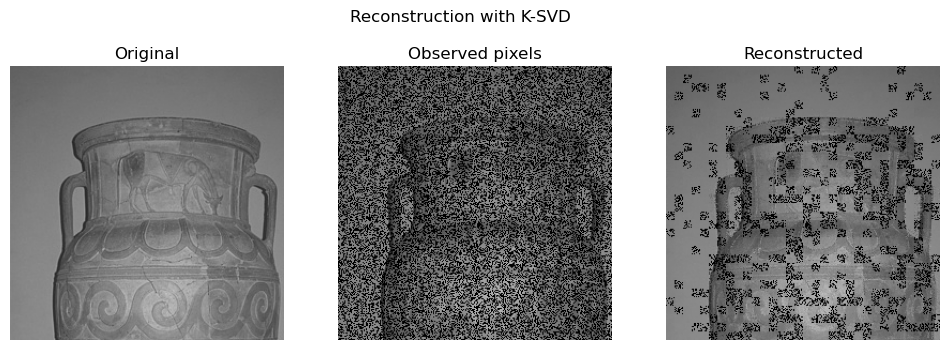

In [10]:
show_results(test_image, X_rec, X_masked = X_corrupted, title="Reconstruction with K-SVD")

## Recommender System Experiments - Netflix Dataset

In [3]:
# 1: Start with a naturally incomplete matrix
X, original_mask = load_netflix_matrix(
            NETFLIX_PATH / "netflix_dense_mtx_0_925_256_movies.csv"
    )
# X shape:
# (4367, 256)
#
# rows = users
# cols = movies
observed_fraction = np.mean(original_mask)
print(f"Observed fraction in Netflix matrix: {observed_fraction:.4f}")

Observed fraction in Netflix matrix: 0.9256


### Reconstruction / matrix completion experiment
= remove some observed ratings and reconstruct them

Deviations from the image setting:
- use **user rating vectors (rows)** as the **signals**
- for reconstruction, the **observed mask** becomes the *original_mask from load + additional holdout*
- skip fixed_atoms
- error goal eps could be ~0.5 rating points instead of the ~5 grey-values
- for the train/test split use hold out entries from the same matrix, unlike using different images as in the image experiments

Test 2: ksvd_recommender_option_a.py with test_option_a.py

Error-Goal Reconstruction

- missing fraction: 0.1;
- N_ATOMS        = 256    # 
- SPARSITY_TRAIN = 10     # max nonzero coefficients during training
- N_ITER         = 20
- EPSILON = 0.5 
- SEED = 42

Result: 
- RMSE: 0.858987; MAE:  0.657788
- Dictionary shape: (256, 256) -> not overcomplete yet -> run for (256, 512)

SVT result (Reconstruction for 90% observed entries): RMSE: 0.7492851125736819; MAE: 0.5811156900883001

Error-Goal Reconstruction

- missing fraction: 0.2;
- N_ATOMS        = 512    
- SPARSITY_TRAIN = 10     # max nonzero coefficients during training
- N_ITER         = 10
- EPSILON = 0.5 
- SEED = 42

Result:
- RMSE: 0.903431; MAE:  0.695932

SVT Result (20% missing entries reconstruction): RMSE 0.7508; MAE 0.5837

Error-Goal Reconstruction

- missing fraction: 0.1;
- N_ATOMS        = 512    
- SPARSITY_TRAIN = 10     # max nonzero coefficients during training
- N_ITER         = 15
- EPSILON = 0.5 
- SEED = 42

Result:
- RMSE: 0.891900; MAE:  0.686167

Error-Goal Reconstruction

- missing fraction: 0.1;
- N_ATOMS        = 1024   
- SPARSITY_TRAIN = 12     # max nonzero coefficients during training
- N_ITER         = 15
- EPSILON = 0.5 
- SEED = 42

Result:
- RMSE: 0.918162; MAE:  0.710140

### Denoising experiment

Dictionary shape: (256, 1024)

n_atoms=1024, sparsity=20, n_iter=20

Input (noisy):
  RMSE: 0.6669
  MAE:  0.1887

Output (denoised):
  RMSE: 0.6658
  MAE:  0.4393

Corrupted entries RMSE (before denoising): 2.111226176327565

Corrupted entries RMSE (after denoising): 1.6669856327171617

Clean entries RMSE (after denoising): 0.42940462432599236



SVT result (denoising with 10% probability of symmetric noise):
- RMSE: 0.6600, 
- Noisy observed RMSE: 0.6701, 
- Corrupted entries RMSE (before denoising): 2.1167, 
- Corrupted entries RMSE (after denoising): 1.77998